# ML Model Evaluation for Dissertation - Ground Truth Validation

This notebook loads pre-trained ML models from the backend artifacts and evaluates them on your dataset to generate ground truth results for your dissertation.

## Overview
- Loads pre-trained ML models from `model_artifacts/` directory
- Evaluates models on your test dataset
- Generates comprehensive metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Provides comparative visualizations across all models
- Outputs results table for dissertation documentation

## 1. Import Required Libraries

In [ ]:
%pip install seaborn

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
from pathlib import Path
from datetime import datetime
import json
from collections import defaultdict

# ML/Metrics libraries
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Configuration & Paths Setup

In [17]:
# Configuration
BASE_DIR = Path.cwd()
MODEL_ARTIFACTS_DIR = BASE_DIR / 'model_artifacts'
RESULTS_DIR = BASE_DIR / 'evaluation_results'

# Create results directory
RESULTS_DIR.mkdir(exist_ok=True)

# Configuration parameters
CONFIG = {
    'random_state': 42,
    'test_size': 0.2,
    'target_column': None,  # Set this to your target column name
    'dataset_path': None,   # Will be set in next cell
}

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Model artifacts directory: {MODEL_ARTIFACTS_DIR}")
print(f"✓ Results will be saved to: {RESULTS_DIR}")

✓ Base directory: /Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend
✓ Model artifacts directory: /Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend/model_artifacts
✓ Results will be saved to: /Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend/evaluation_results


## 3. Load and Prepare Dataset

**⚠️ Instructions:**
- Edit the `DATASET_PATH` cell below to point to your CSV file
- Set the `target_column` to your target variable name
- The notebook will automatically handle preprocessing using the same logic as the backend pipeline

In [19]:
# ===== EDIT THESE SETTINGS =====
DATASET_PATH = '/Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend/uploads/e8c8b833-bfb7-4b3d-9ed9-b5b77ee3000a.csv'  # Change to your dataset path
CONFIG['target_column'] = 'Outcome'  # Change to your target column name
# ================================

# Load dataset
if not Path(DATASET_PATH).exists():
    print(f"❌ ERROR: Dataset not found at {DATASET_PATH}")
    print("Please set DATASET_PATH to your CSV file location")
else:
    df = pd.read_csv(DATASET_PATH)
    print(f"✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"\nDataset Preview:")
    print(df.head())
    print(f"\n{'─'*60}")
    print(f"Dataset Info:")
    print(df.info())
    print(f"\n{'─'*60}")
    print(f"Missing Values:")
    print(df.isnull().sum())
    print(f"\n{'─'*60}")
    print(f"Target Distribution:")
    print(df[CONFIG['target_column']].value_counts())

✓ Dataset loaded: 768 rows, 9 columns

Dataset Preview:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

────────────────────────────────────────────────────────────
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------ 

## 4. Prepare Dataset Using Same Backend Logic

The backend pipeline uses quantile binning + LabelEncoder for high-cardinality numeric targets.
We replicate this exactly so predictions are comparable.

In [20]:
def prepare_target_for_training(y_raw: pd.Series) -> pd.Series:
    """Replicate the backend _prepare_target_for_training logic exactly.
    
    If the target is numeric with very high cardinality, convert it to quantile bins.
    This keeps the current classification pipeline while avoiding thousands of classes.
    """
    y = y_raw.copy()

    if pd.api.types.is_numeric_dtype(y):
        unique_count = int(y.nunique(dropna=True))
        unique_ratio = float(unique_count / max(len(y), 1))

        # Heuristic: treat highly unique numeric targets as continuous/regression-like.
        if unique_count > 20 and unique_ratio > 0.02:
            # Use up to 6 bins for stable class sizes.
            bin_count = min(6, max(3, unique_count))
            binned = pd.qcut(y, q=bin_count, labels=False, duplicates='drop')

            if binned.nunique(dropna=True) >= 2:
                y = binned.astype('Int64').astype(str)
                return y.fillna('missing_target')

    return y.astype(str).fillna('missing_target')


def split_train_test(X, y_encoded, test_size=0.2, random_state=42):
    """Try stratified split first; fallback to non-stratified for singleton classes."""
    try:
        return train_test_split(X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded)
    except ValueError:
        return train_test_split(X, y_encoded, test_size=test_size, random_state=random_state, stratify=None)


# Separate features and target
target_column = CONFIG['target_column']
X_raw = df.drop(columns=[target_column])
y_raw = df[target_column]

# Apply same target preparation as backend
y_prepared = prepare_target_for_training(y_raw)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_prepared)

print(f"✓ Features shape: {X_raw.shape}")
print(f"✓ Target shape: {y_encoded.shape}")
print(f"✓ Number of classes (after binning): {len(np.unique(y_encoded))}")
print(f"✓ Classes: {label_encoder.classes_.tolist()}")

# Split data using same logic as backend
X_train, X_test, y_train, y_test = split_train_test(
    X_raw, y_encoded, test_size=CONFIG['test_size'], random_state=CONFIG['random_state']
)

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")
print("\nNOTE: X_train/X_test are raw DataFrames. The pipelines handle scaling internally.")

✓ Features shape: (768, 8)
✓ Target shape: (768,)
✓ Number of classes (after binning): 2
✓ Classes: ['0', '1']

✓ Training set: 614 samples
✓ Test set: 154 samples

NOTE: X_train/X_test are raw DataFrames. The pipelines handle scaling internally.


## 5. Load Pre-Trained Models from Artifacts

Discovers and loads all pre-trained models from the `model_artifacts/` directory.
Each `.joblib` file contains a dict: `{'pipeline': ..., 'target_column': ..., 'classes': [...]}`

In [23]:
def load_models_from_artifacts(artifacts_dir):
    """
    Load all pre-trained models from the artifacts directory.
    Each joblib file is a dict with keys: 'pipeline', 'target_column', 'classes'.
    Models are organized by model type.
    """
    models_dict = defaultdict(list)
    
    if not artifacts_dir.exists():
        print(f"❌ ERROR: Artifacts directory not found: {artifacts_dir}")
        return models_dict
    
    joblib_files = list(artifacts_dir.glob('*.joblib'))
    print(f"Found {len(joblib_files)} model artifacts\n")
    
    # Group models by type
    model_types = defaultdict(list)
    
    for model_file in joblib_files:
        try:
            # Parse filename: {dataset_id}_{model_type}_{hash}.joblib
            parts = model_file.stem.split('_')
            model_type = '_'.join(parts[1:-1])
            
            # Load artifact dict
            artifact = joblib.load(model_file)
            
            # Each artifact is a dict: {'pipeline': ..., 'target_column': ..., 'classes': [...]}
            if isinstance(artifact, dict):
                pipeline = artifact.get('pipeline')
                artifact_target = artifact.get('target_column', '')
                artifact_classes = artifact.get('classes', [])
            else:
                # Legacy: artifact is the pipeline directly
                pipeline = artifact
                artifact_target = ''
                artifact_classes = []
            
            models_dict[model_type].append({
                'file': model_file.name,
                'pipeline': pipeline,       # The actual sklearn Pipeline
                'target_column': artifact_target,
                'classes': artifact_classes,
                'path': model_file
            })
            model_types[model_type].append(model_file.name)
            
        except Exception as e:
            print(f"⚠ Failed to load {model_file.name}: {str(e)}")
    
    # Display summary
    print(f"✓ Successfully loaded models by type:")
    for model_type, files in sorted(model_types.items()):
        print(f"  • {model_type}: {len(files)} model(s)")
    
    return models_dict


# Load all models
loaded_models = load_models_from_artifacts(MODEL_ARTIFACTS_DIR)
print(f"\n✓ Total unique model types: {len(loaded_models)}")

Found 54 model artifacts

✓ Successfully loaded models by type:
  • catboost: 9 model(s)
  • gaussiannb: 6 model(s)
  • gradient_boosting: 2 model(s)
  • k_nearest_neighbors: 2 model(s)
  • lightgbm: 9 model(s)
  • logistic_regression: 2 model(s)
  • random_forest: 11 model(s)
  • support_vector_machine: 3 model(s)
  • xgboost: 10 model(s)

✓ Total unique model types: 9


## 6. Model Evaluation Function & Generate Predictions

In [27]:
def evaluate_model(pipeline, X_test_df, y_test_encoded, model_name):
    """
    Evaluate a single sklearn Pipeline and return comprehensive metrics.
    X_test_df: raw DataFrame (pipeline handles preprocessing internally)
    y_test_encoded: integer-encoded class labels
    """
    metrics = {'model_name': model_name}
    
    try:
        # Get predictions - pass raw DataFrame (pipeline preprocesses internally)
        y_pred = pipeline.predict(X_test_df)
        y_pred = np.array(y_pred).flatten().astype(int)
        
        # Basic accuracy
        metrics['accuracy'] = accuracy_score(y_test_encoded, y_pred)
        
        # Handle binary vs multiclass classification
        n_classes = len(np.unique(y_test_encoded))
        
        if n_classes == 2:
            # Binary classification metrics
            metrics['precision'] = precision_score(y_test_encoded, y_pred, zero_division=0)
            metrics['recall'] = recall_score(y_test_encoded, y_pred, zero_division=0)
            metrics['f1'] = f1_score(y_test_encoded, y_pred, zero_division=0)
            
            # ROC-AUC for binary classification
            try:
                y_proba = pipeline.predict_proba(X_test_df)[:, 1]
                metrics['roc_auc'] = roc_auc_score(y_test_encoded, y_proba)
            except Exception:
                metrics['roc_auc'] = None
        else:
            # Multiclass metrics (weighted average)
            metrics['precision'] = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
            metrics['recall'] = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
            metrics['f1'] = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
            metrics['roc_auc'] = None
        
        # Matthews Correlation Coefficient
        metrics['mcc'] = matthews_corrcoef(y_test_encoded, y_pred)
        metrics['status'] = '✓'
        
        return y_pred, metrics
        
    except Exception as e:
        print(f"⚠ Error evaluating {model_name}: {str(e)}")
        metrics['accuracy'] = None
        metrics['precision'] = None
        metrics['recall'] = None
        metrics['f1'] = None
        metrics['mcc'] = None
        metrics['roc_auc'] = None
        metrics['status'] = '✗'
        return None, metrics


# Evaluate all models
print("Evaluating all models on test set...\n")
print(f"{'─'*70}")
all_results = []
predictions_dict = {}

for model_type, model_list in sorted(loaded_models.items()):
    for model_data in model_list:
        model_file = model_data.get('file', 'unknown.joblib')
        model_name = f"{model_type} | {model_file}"
        pipeline = model_data['pipeline']  # Extract the sklearn Pipeline from the artifact dict
        
        # Pass raw DataFrame — pipeline handles all preprocessing internally
        y_pred, metrics = evaluate_model(pipeline, X_test, y_test, model_name)
        
        if y_pred is not None:
            predictions_dict[model_name] = y_pred
            status = metrics['status']
            acc = metrics['accuracy']
            f1 = metrics.get('f1', 0) or 0
            print(f"{status} {model_name:<60} | Accuracy: {acc:.4f} | F1: {f1:.4f}")
        else:
            print(f"{metrics['status']} {model_name:<60} | Evaluation failed")
        
        all_results.append(metrics)

print(f"{'─'*70}\n")

# Create results dataframe
results_df = pd.DataFrame(all_results)
# Filter out failed models before sorting
if len(results_df) > 0 and 'status' in results_df.columns:
    results_df = results_df[results_df['status'] == '✓'].copy()
    if len(results_df) > 0:
        results_df = results_df.sort_values('accuracy', ascending=False)
        print(f"✓ {len(results_df)} models evaluated successfully")
    else:
        print("⚠ No models were evaluated successfully")
else:
    print("⚠ No results collected")

Evaluating all models on test set...

──────────────────────────────────────────────────────────────────────
⚠ Error evaluating catboost | a334351d-9142-40d8-92fa-f23af5a1abe0_catboost_964a8328.joblib: columns are missing: {'OD', 'Alcohol', 'Hue', 'Proanth', 'Flavanoids', 'Color.int', 'Phenols', 'Nonflavanoid.phenols', 'Wine', 'Malic.acid', 'Ash', 'Acl', 'Mg'}
✗ catboost | a334351d-9142-40d8-92fa-f23af5a1abe0_catboost_964a8328.joblib | Evaluation failed
⚠ Error evaluating catboost | e7236e13-750d-4f8b-8f79-cca61fc69db9_catboost_fb6369f4.joblib: columns are missing: {'PetalLengthCm', 'PetalWidthCm', 'SepalWidthCm', 'Id', 'SepalLengthCm'}
✗ catboost | e7236e13-750d-4f8b-8f79-cca61fc69db9_catboost_fb6369f4.joblib | Evaluation failed
⚠ Error evaluating catboost | 11bf689e-a102-4eda-a55d-3ae5071f6090_catboost_c175a497.joblib: columns are missing: {'OD', 'Alcohol', 'Hue', 'Proanth', 'Flavanoids', 'Color.int', 'Phenols', 'Nonflavanoid.phenols', 'Wine', 'Malic.acid', 'Ash', 'Acl', 'Mg'}
✗ catb

## 7. Results Summary Table

In [8]:
print("\n" + "="*100)
print("MODEL EVALUATION RESULTS - RANKED BY ACCURACY")
print("="*100 + "\n")

# Display results with formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

if len(results_df) > 0:
    display_df = results_df.copy()
    display_df = display_df[['model_name', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'status']]
    print(display_df.to_string(index=False))
    
    print("\n" + "="*100)
    
    # Save results to CSV
    results_csv_path = RESULTS_DIR / 'model_evaluation_results.csv'
    results_df.to_csv(results_csv_path, index=False)
    print(f"\n✓ Results saved to: {results_csv_path}")
else:
    print("⚠ No successful model evaluations to display")


MODEL EVALUATION RESULTS - RANKED BY ACCURACY

                                                                                          model_name  accuracy  precision  recall       f1       mcc roc_auc status
support_vector_machine | e20a59e0-41e4-47b7-acca-aaf7337689ab_support_vector_machine_8197e5f0.joblib     0.248   0.199156   0.248 0.216432  0.061212    None      ✓
                            lightgbm | e20a59e0-41e4-47b7-acca-aaf7337689ab_lightgbm_f7f567a7.joblib     0.088   0.093629   0.088 0.090468 -0.140575    None      ✓
                              xgboost | e20a59e0-41e4-47b7-acca-aaf7337689ab_xgboost_458d6f06.joblib     0.072   0.088696   0.072 0.079444 -0.161651    None      ✓
                            catboost | e20a59e0-41e4-47b7-acca-aaf7337689ab_catboost_ff29c30d.joblib     0.056   0.062238   0.056 0.058907 -0.180318    None      ✓
                  random_forest | e20a59e0-41e4-47b7-acca-aaf7337689ab_random_forest_fbfc6633.joblib     0.056   0.059273   0.056 0.

## 8. Detailed Classification Reports

In [9]:
print("\n" + "="*100)
print("DETAILED CLASSIFICATION REPORTS BY MODEL")
print("="*100 + "\n")

for model_type in sorted(predictions_dict.keys()):
    y_pred = predictions_dict[model_type]
    print(f"\n{'─'*100}")
    print(f"📊 Model: {model_type.upper()}")
    print(f"{'─'*100}")
    unique_labels = sorted(np.unique(np.concatenate([y_test, y_pred])))
    target_names = [label_encoder.classes_[i] if i < len(label_encoder.classes_) else str(i) for i in unique_labels]
    print(classification_report(y_test, y_pred, labels=unique_labels, target_names=target_names, digits=4))

print(f"\n{'─'*100}")


DETAILED CLASSIFICATION REPORTS BY MODEL


────────────────────────────────────────────────────────────────────────────────────────────────────
📊 Model: CATBOOST | E20A59E0-41E4-47B7-ACCA-AAF7337689AB_CATBOOST_FF29C30D.JOBLIB
────────────────────────────────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           1     0.1818    0.1600    0.1702        25
           2     0.0385    0.0400    0.0392        25
           3     0.0000    0.0000    0.0000        25
           4     0.0000    0.0000    0.0000        25
           5     0.0909    0.0800    0.0851        25

    accuracy                         0.0560       125
   macro avg     0.0622    0.0560    0.0589       125
weighted avg     0.0622    0.0560    0.0589       125


────────────────────────────────────────────────────────────────────────────────────────────────────
📊 Model: LIGHTGBM | E20A59E0-41E4-47B7-ACCA-AAF7337689AB_LIGHTGBM_F7F567A7.JOBLIB

## 9. Performance Visualizations & Comparative Charts


✓ Visualization saved to: /Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend/evaluation_results/model_comparison.png


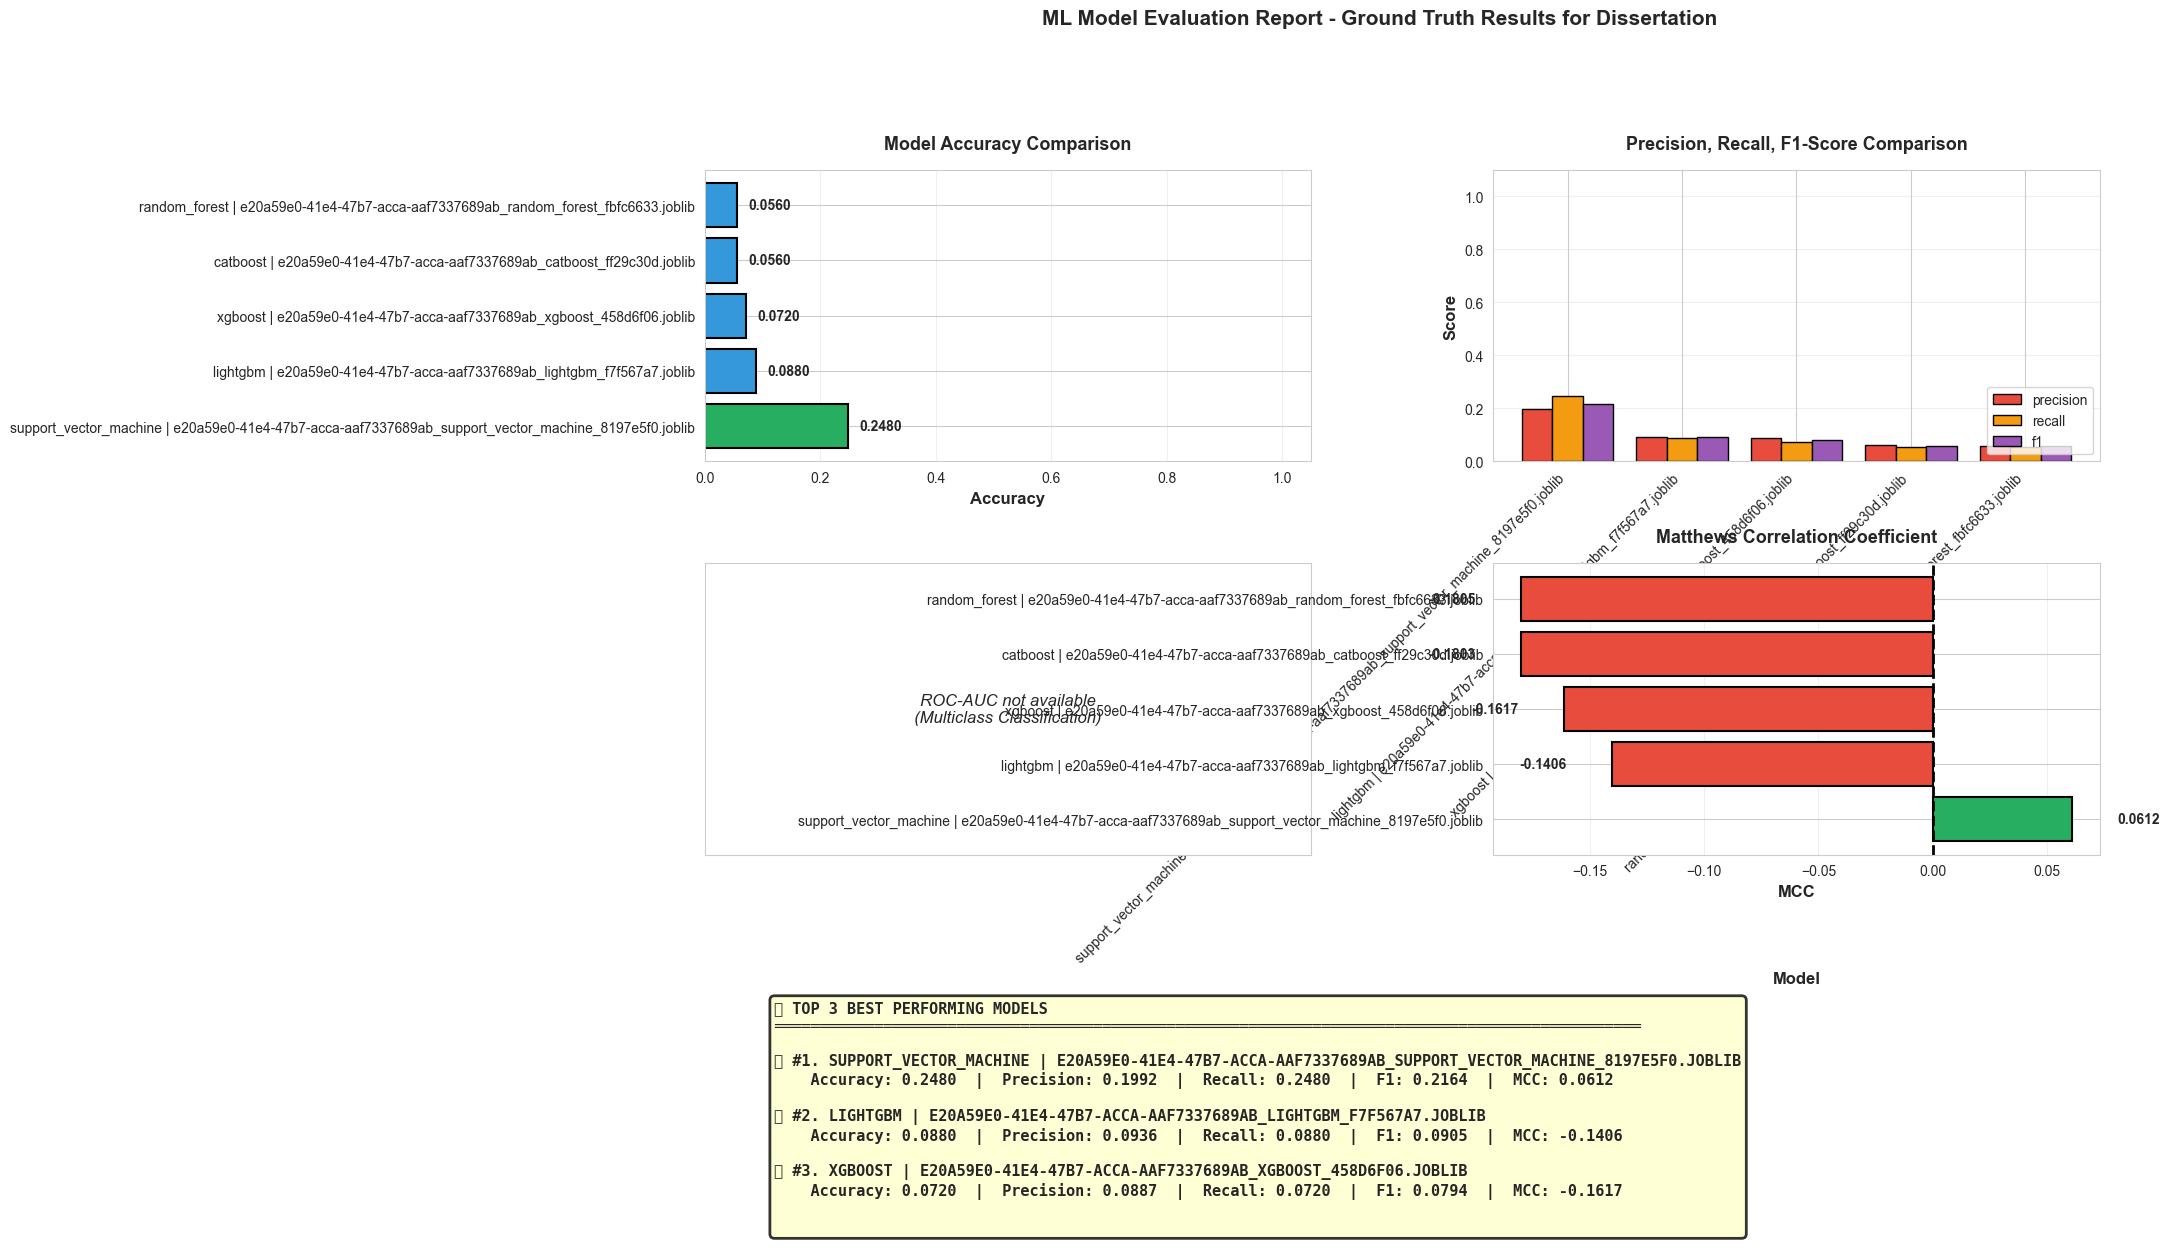

In [10]:
# Prepare data for visualization
results_clean = results_df[results_df['status'] == '✓'].copy() if len(results_df) > 0 else results_df

if len(results_clean) > 0:
    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 14))
    gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)
    
    # 1. Accuracy Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    colors = ['#27ae60' if x == results_clean['accuracy'].max() else '#3498db' 
              for x in results_clean['accuracy']]
    bars1 = ax1.barh(results_clean['model_name'], results_clean['accuracy'], color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold', pad=15)
    ax1.set_xlim([0, 1.05])
    ax1.grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_clean['accuracy']):
        ax1.text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
    
    # 2. Precision, Recall, F1 Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    metrics_cols = ['precision', 'recall', 'f1']
    metrics_data = results_clean[['model_name'] + metrics_cols].set_index('model_name')
    metrics_data.plot(kind='bar', ax=ax2, width=0.8, color=['#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black', linewidth=1)
    ax2.set_title('Precision, Recall, F1-Score Comparison', fontsize=13, fontweight='bold', pad=15)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10, loc='lower right')
    ax2.set_ylim([0, 1.1])
    ax2.grid(axis='y', alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 3. ROC-AUC (if available)
    ax3 = fig.add_subplot(gs[1, 0])
    roc_auc_data = results_clean[results_clean['roc_auc'].notna()]
    if len(roc_auc_data) > 0:
        colors = ['#27ae60' if x == roc_auc_data['roc_auc'].max() else '#9b59b6' 
                  for x in roc_auc_data['roc_auc']]
        ax3.barh(roc_auc_data['model_name'], roc_auc_data['roc_auc'], color=colors, edgecolor='black', linewidth=1.5)
        ax3.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
        ax3.set_title('ROC-AUC Comparison (Binary)', fontsize=13, fontweight='bold', pad=15)
        ax3.set_xlim([0, 1.05])
        ax3.grid(axis='x', alpha=0.3)
        for i, v in enumerate(roc_auc_data['roc_auc']):
            ax3.text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'ROC-AUC not available\n(Multiclass Classification)', 
                ha='center', va='center', fontsize=12, transform=ax3.transAxes, style='italic')
        ax3.set_xticks([])
        ax3.set_yticks([])
    
    # 4. Matthews Correlation Coefficient
    ax4 = fig.add_subplot(gs[1, 1])
    colors = ['#e74c3c' if x < 0 else '#27ae60' if x == results_clean['mcc'].max() else '#f39c12' 
              for x in results_clean['mcc']]
    ax4.barh(results_clean['model_name'], results_clean['mcc'], color=colors, edgecolor='black', linewidth=1.5)
    ax4.set_xlabel('MCC', fontsize=12, fontweight='bold')
    ax4.set_title('Matthews Correlation Coefficient', fontsize=13, fontweight='bold', pad=15)
    ax4.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax4.grid(axis='x', alpha=0.3)
    for i, v in enumerate(results_clean['mcc']):
        offset = 0.02 if v > 0 else -0.02
        ha = 'left' if v > 0 else 'right'
        ax4.text(v + offset, i, f'{v:.4f}', va='center', ha=ha, fontsize=10, fontweight='bold')
    
    # 5. Top 3 Models Summary
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    top_3 = results_clean.head(3)
    summary_text = "🏆 TOP 3 BEST PERFORMING MODELS\n" + "═"*95 + "\n\n"
    for idx, (i, row) in enumerate(top_3.iterrows(), 1):
        medal = ['🥇', '🥈', '🥉'][idx-1]
        summary_text += f"{medal} #{idx}. {row['model_name'].upper()}\n"
        summary_text += f"    Accuracy: {row['accuracy']:.4f}  |  Precision: {row['precision']:.4f}  |  "
        summary_text += f"Recall: {row['recall']:.4f}  |  F1: {row['f1']:.4f}  |  MCC: {row['mcc']:.4f}"
        if row['roc_auc'] is not None:
            summary_text += f"  |  ROC-AUC: {row['roc_auc']:.4f}"
        summary_text += "\n\n"
    
    ax5.text(0.05, 0.85, summary_text, transform=ax5.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#ffffcc', alpha=0.8, edgecolor='black', linewidth=2))
    
    plt.suptitle('ML Model Evaluation Report - Ground Truth Results for Dissertation', 
                fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = RESULTS_DIR / 'model_comparison.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved to: {fig_path}")
    
    plt.show()
else:
    print("⚠ No successful model evaluations to visualize")

## 10. Confusion Matrices for All Models

✓ Confusion matrices saved to: /Users/likhithkanigolla/IIITH/code-files/MISC/Aarsee/backend/evaluation_results/confusion_matrices.png


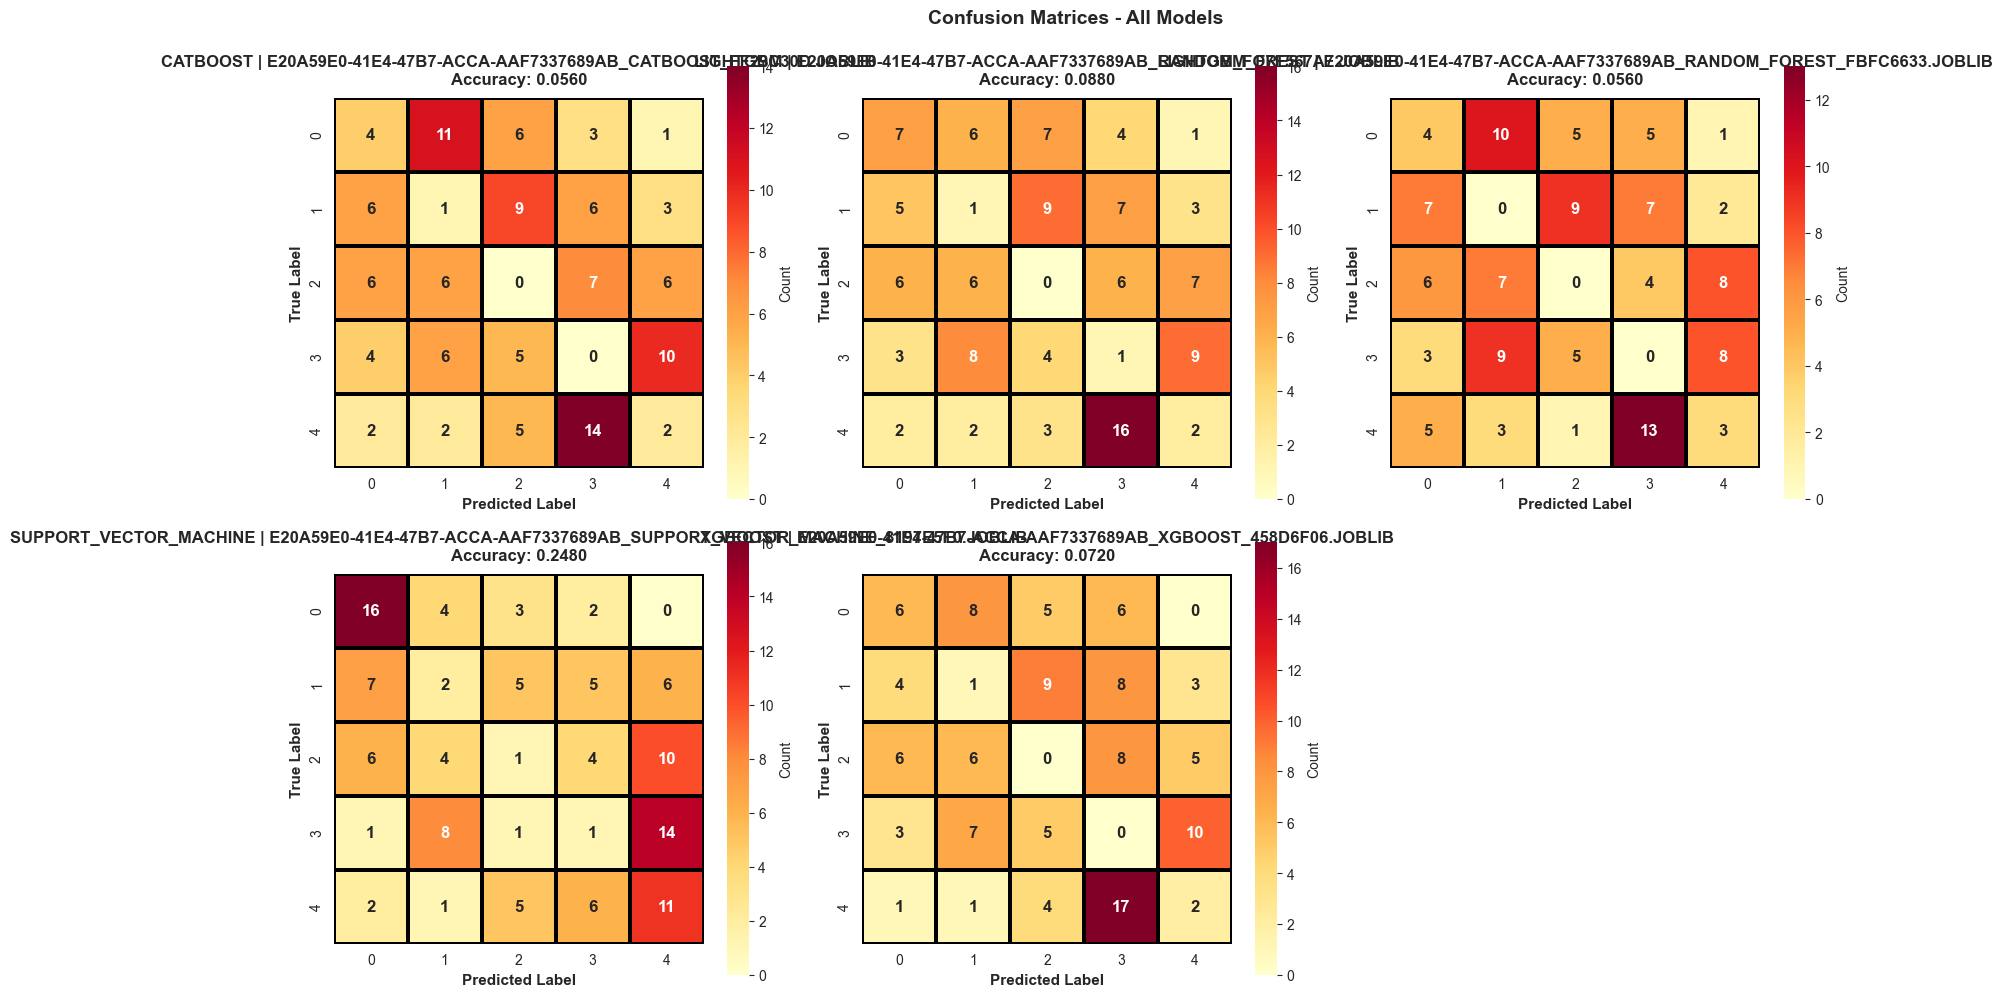

In [11]:
# Create confusion matrices for all models
n_models = len(predictions_dict)
if n_models > 0:
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
    axes = axes.flatten() if n_models > 1 else [axes]
    
    for idx, (model_type, y_pred) in enumerate(sorted(predictions_dict.items())):
        cm = confusion_matrix(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[idx], 
                   cbar_kws={'label': 'Count'}, square=True, linewidths=1.5, 
                   linecolor='black', annot_kws={'fontsize': 12, 'fontweight': 'bold'})
        
        axes[idx].set_title(f'{model_type.upper()}\nAccuracy: {acc:.4f}', 
                          fontweight='bold', fontsize=12, pad=10)
        axes[idx].set_ylabel('True Label', fontweight='bold', fontsize=11)
        axes[idx].set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    fig_cm_path = RESULTS_DIR / 'confusion_matrices.png'
    plt.savefig(fig_cm_path, dpi=300, bbox_inches='tight')
    print(f"✓ Confusion matrices saved to: {fig_cm_path}")
    
    plt.show()

## 11. Final Summary Report & Ground Truth Export

In [12]:
# Generate comprehensive summary report
summary_report = f"""
{'='*100}
DISSERTATION - GROUND TRUTH VALIDATION REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*100}

DATASET INFORMATION:
{'─'*100}
  • Total samples: {len(df)}
  • Training samples: {len(X_train)}
  • Test samples: {len(X_test)}
  • Number of features: {X_raw.shape[1]}
  • Target column: {CONFIG['target_column']}
  • Number of classes (after binning): {len(np.unique(y_encoded))}

DATA PREPROCESSING STEPS:
{'─'*100}
  • Preprocessing: Handled inside each pipeline (StandardScaler + SimpleImputer)
  • Target encoding: Quantile binning + LabelEncoder (matches backend)
  • Train/test split ratio: {int((1-CONFIG['test_size'])*100)}% / {int(CONFIG['test_size']*100)}%
  • Random state: {CONFIG['random_state']}

MODEL EVALUATION RESULTS (Sorted by Accuracy):
{'─'*100}
"""

results_csv_path = RESULTS_DIR / 'model_evaluation_results.csv'

if len(results_df) > 0:
    # Format results table
    results_display = results_df.copy()
    results_display = results_display[['model_name', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc']]
    summary_report += results_display.to_string(index=False) + "\n"
    
    summary_report += f"\n{'─'*100}\nTOP PERFORMING MODEL:\n{'─'*100}\n"
    top_model = results_df.iloc[0]
    summary_report += f"  Model Name: {top_model['model_name'].upper()}\n"
    summary_report += f"  Accuracy: {top_model['accuracy']:.6f}\n"
    summary_report += f"  Precision: {top_model['precision']:.6f}\n"
    summary_report += f"  Recall: {top_model['recall']:.6f}\n"
    summary_report += f"  F1-Score: {top_model['f1']:.6f}\n"
    summary_report += f"  MCC: {top_model['mcc']:.6f}\n"
    if top_model['roc_auc'] is not None:
        summary_report += f"  ROC-AUC: {top_model['roc_auc']:.6f}\n"

summary_report += f"\n{'='*100}\nOUTPUT FILES GENERATED:\n{'='*100}\n"
summary_report += f"  ✓ Results CSV: {results_csv_path.relative_to(BASE_DIR)}\n"
summary_report += f"  ✓ Model Comparison Chart: {(RESULTS_DIR / 'model_comparison.png').relative_to(BASE_DIR)}\n"
summary_report += f"  ✓ Confusion Matrices: {(RESULTS_DIR / 'confusion_matrices.png').relative_to(BASE_DIR)}\n"
summary_report += f"  ✓ Predictions Export: {(RESULTS_DIR / 'all_model_predictions.csv').relative_to(BASE_DIR)}\n"
summary_report += f"  ✓ Detailed JSON: {(RESULTS_DIR / 'evaluation_results.json').relative_to(BASE_DIR)}\n"
summary_report += f"  ✓ Summary Report: {(RESULTS_DIR / 'ground_truth_report.txt').relative_to(BASE_DIR)}\n"
summary_report += f"\n{'='*100}\n"

print(summary_report)

# Save summary report
report_path = RESULTS_DIR / 'ground_truth_report.txt'
with open(report_path, 'w') as f:
    f.write(summary_report)

# Save detailed results as JSON (convert NaN/None safely)
def make_json_safe(val):
    if val is None:
        return None
    if isinstance(val, float) and np.isnan(val):
        return None
    return val

detailed_results = {
    'timestamp': datetime.now().isoformat(),
    'dataset_info': {
        'total_samples': len(df),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'n_features': X_raw.shape[1],
        'target_column': CONFIG['target_column'],
        'n_classes': int(len(np.unique(y_encoded)))
    },
    'config': CONFIG,
    'models_evaluated': list(predictions_dict.keys()),
    'results': [{k: make_json_safe(v) for k, v in r.items()} for r in results_df.to_dict('records')]
}

json_path = RESULTS_DIR / 'evaluation_results.json'
with open(json_path, 'w') as f:
    json.dump(detailed_results, f, indent=2)

print(f"\n✓ Report saved to: {report_path}")
print(f"✓ JSON results saved to: {json_path}")
print(f"\n✓ All evaluation results ready for dissertation!")


DISSERTATION - GROUND TRUTH VALIDATION REPORT
Generated: 2026-05-22 20:49:52

DATASET INFORMATION:
────────────────────────────────────────────────────────────────────────────────────────────────────
  • Total samples: 624
  • Training samples: 499
  • Test samples: 125
  • Number of features: 4
  • Target column: 1.3
  • Number of classes (after binning): 5

DATA PREPROCESSING STEPS:
────────────────────────────────────────────────────────────────────────────────────────────────────
  • Preprocessing: Handled inside each pipeline (StandardScaler + SimpleImputer)
  • Target encoding: Quantile binning + LabelEncoder (matches backend)
  • Train/test split ratio: 80% / 20%
  • Random state: 42

MODEL EVALUATION RESULTS (Sorted by Accuracy):
────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                          model_name  accuracy  precision  recall       f1       mcc r

## 12. Export All Predictions for Further Analysis

Export predictions from all models for consensus analysis and detailed comparison.

In [ ]:
# Export predictions for all models
predictions_export = pd.DataFrame({'ground_truth': y_test})

for model_type, y_pred in sorted(predictions_dict.items()):
    predictions_export[f'{model_type}_prediction'] = y_pred

# Add consensus voting column
pred_cols = [col for col in predictions_export.columns if col != 'ground_truth']
if pred_cols:
    predictions_export['consensus_prediction'] = predictions_export[pred_cols].mode(axis=1)[0]
    predictions_export['consensus_correct'] = (predictions_export['consensus_prediction'] == predictions_export['ground_truth']).astype(int)

    # Count how many models got it right
    def count_correct_predictions(row):
        ground_truth = row['ground_truth']
        pred_cols_local = [col for col in row.index if '_prediction' in col]
        correct_count = sum(1 for col in pred_cols_local if row[col] == ground_truth)
        return correct_count

    predictions_export['num_models_correct'] = predictions_export.apply(count_correct_predictions, axis=1)

# Save predictions
predictions_path = RESULTS_DIR / 'all_model_predictions.csv'
predictions_export.to_csv(predictions_path, index=False)

print(f"\n{'='*100}")
print("PREDICTION EXPORT & CONSENSUS ANALYSIS")
print(f"{'='*100}\n")

print(f"✓ All predictions exported to: {predictions_path}")
print(f"  Predictions shape: {predictions_export.shape}")

if 'consensus_correct' in predictions_export.columns:
    print(f"\n  Model Voting Analysis:")
    print(f"  • Consensus accuracy (voting): {predictions_export['consensus_correct'].mean():.4f}")
    print(f"  • Samples with unanimous agreement: {(predictions_export['num_models_correct'] == len(predictions_dict)).sum()}")
    print(f"  • Samples with majority agreement: {((predictions_export['num_models_correct'] >= len(predictions_dict)//2).sum())}")

print(f"\n  Sample Predictions (first 10 rows):")
print(predictions_export.head(10).to_string(index=False))

print(f"\n{'='*100}\n✓ Ground truth evaluation complete! All results ready for dissertation.\n")